In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 2. LOAD FEATURE ENGINEERED DATA
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")

print("Shape:", df.shape)
df.head()

Shape: (550502, 18)


,cuisine_type,restaurant_capacity,restaurant_rating,chef_count,efficiency_score,total_items,item_complexity_score,queue_length,kitchen_utilization,weather,festival_flag,weekend,prep_time,restaurant_avg_prep,hour_sin,hour_cos,congestion_complexity,log_queue
0,0,10,3.6,5,0.876097,4,6.24,0.0,0.0,1,1,0,25.77,26.665551,0.0,1.0,0.0,0.0
1,3,13,3.0,8,0.812020,6,14.66,0.0,0.0,1,1,0,55.89,40.338372,0.0,1.0,0.0,0.0
2,5,5,4.5,3,0.994893,4,4.46,0.0,0.0,1,1,0,8.59,24.787594,0.0,1.0,0.0,0.0
3,0,7,4.1,4,0.978308,5,11.80,0.0,0.0,1,1,0,33.36,30.619106,0.0,1.0,0.0,0.0
4,6,5,4.1,3,0.980710,2,3.63,0.0,0.0,1,1,0,24.25,30.114836,0.0,1.0,0.0,0.0


In [2]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 2. LOAD FEATURE ENGINEERED DATA
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")

print("Shape:", df.shape)
df.head()

Shape: (550502, 18)


,cuisine_type,restaurant_capacity,restaurant_rating,chef_count,efficiency_score,total_items,item_complexity_score,queue_length,kitchen_utilization,weather,festival_flag,weekend,prep_time,restaurant_avg_prep,hour_sin,hour_cos,congestion_complexity,log_queue
0,0,10,3.6,5,0.876097,4,6.24,0.0,0.0,1,1,0,25.77,26.665551,0.0,1.0,0.0,0.0
1,3,13,3.0,8,0.812020,6,14.66,0.0,0.0,1,1,0,55.89,40.338372,0.0,1.0,0.0,0.0
2,5,5,4.5,3,0.994893,4,4.46,0.0,0.0,1,1,0,8.59,24.787594,0.0,1.0,0.0,0.0
3,0,7,4.1,4,0.978308,5,11.80,0.0,0.0,1,1,0,33.36,30.619106,0.0,1.0,0.0,0.0
4,6,5,4.1,3,0.980710,2,3.63,0.0,0.0,1,1,0,24.25,30.114836,0.0,1.0,0.0,0.0


In [3]:
# Separate features and target
X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (550502, 17)
Target shape: (550502,)


In [4]:
# 80-20 time-based split

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (440401, 17)
Test size: (110101, 17)


In [5]:
# Initialize model

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

# Train
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1392
[LightGBM] [Info] Number of data points in the train set: 440401, number of used features: 17
[LightGBM] [Info] Start training from score 23.603445


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 4))

MAE: 2.001
RMSE: 3.628
R2 Score: 0.8775


In [8]:
# Recreate peak hour flag from cyclical encoding (approximation)
# Better if you kept original peak flag in feature engineering

df_test = df.iloc[split_index:].copy()
df_test["prediction"] = y_pred

# Approximate peak using weekend or high congestion
peak_condition = df_test["kitchen_utilization"] > 0.8

peak_mae = mean_absolute_error(
    df_test[peak_condition]["prep_time"],
    df_test[peak_condition]["prediction"]
)

normal_mae = mean_absolute_error(
    df_test[~peak_condition]["prep_time"],
    df_test[~peak_condition]["prediction"]
)

print("MAE during Congestion:", round(peak_mae, 3))
print("MAE during Normal:", round(normal_mae, 3))

MAE during Congestion: 2.511
MAE during Normal: 1.959


                  feature  importance
6   item_complexity_score        3270
12    restaurant_avg_prep        1890
8     kitchen_utilization        1774
15  congestion_complexity        1484
7            queue_length        1181
4        efficiency_score         938
13               hour_sin         694
1     restaurant_capacity         682
2       restaurant_rating         634
14               hour_cos         605
9                 weather         554
0            cuisine_type         436
5             total_items         334
11                weekend         228
3              chef_count         185


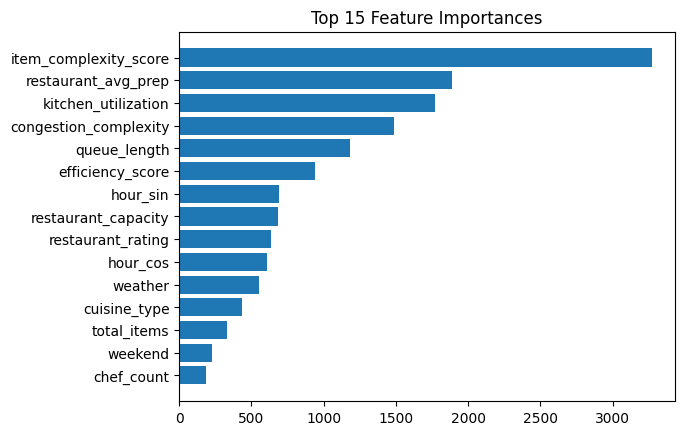

In [9]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importances.head(15))

plt.figure()
plt.barh(importances["feature"][:15], importances["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

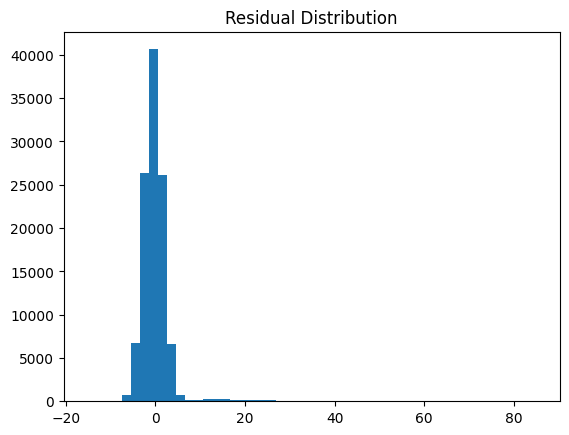

Residual Mean: -0.022


In [10]:
residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

print("Residual Mean:", round(residuals.mean(), 3))

In [11]:
import joblib

joblib.dump(model, "kpt_lightgbm_model.pkl")
print("Model saved successfully.")

Model saved successfully.


Dataset shape: (550502, 18)

Running TimeSeries Cross Validation...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1298
[LightGBM] [Info] Number of data points in the train set: 91752, number of used features: 17
[LightGBM] [Info] Start training from score 23.283518
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

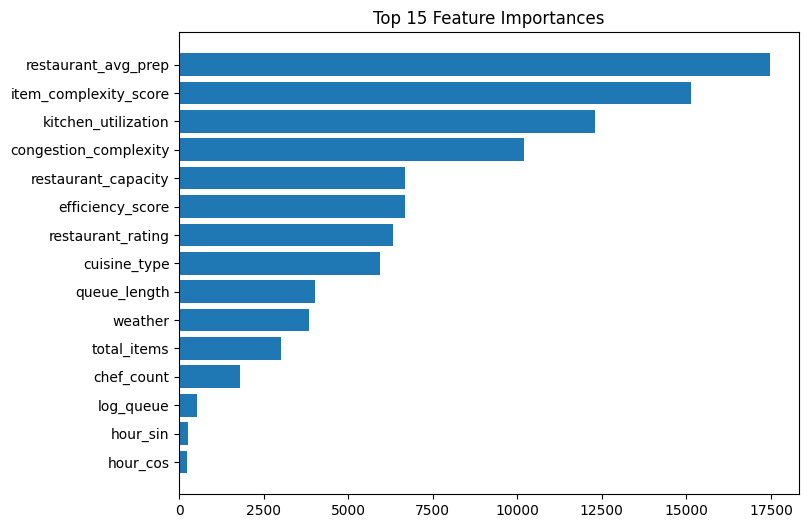


Model saved successfully.


In [12]:
# ==========================================
# FULL OPTIMIZED LIGHTGBM TRAINING PIPELINE
# ==========================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")

# Separate features and target
X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Dataset shape:", df.shape)

# ==========================================
# TIME SERIES CROSS VALIDATION
# ==========================================

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

print("\nRunning TimeSeries Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        objective="huber",
        alpha=0.9,
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=10,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.3,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    mae_scores.append(mae)

    print(f"Fold {fold+1} MAE: {round(mae, 3)}")

print("\nAverage CV MAE:", round(np.mean(mae_scores), 3))

# ==========================================
# FINAL TRAIN-TEST SPLIT (80-20)
# ==========================================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# ==========================================
# FINAL MODEL TRAINING
# ==========================================

final_model = lgb.LGBMRegressor(
    objective="huber",
    alpha=0.9,
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=10,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.3,
    random_state=42
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(100)]
)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = final_model.predict(X_test)

# ==========================================
# EVALUATION METRICS
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nFINAL TEST PERFORMANCE")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 4))

# ==========================================
# CONGESTION PERFORMANCE
# ==========================================

df_test = df.iloc[split_index:].copy()
df_test["prediction"] = y_pred

congestion_condition = df_test["kitchen_utilization"] > 0.8

mae_congestion = mean_absolute_error(
    df_test[congestion_condition]["prep_time"],
    df_test[congestion_condition]["prediction"]
)

mae_normal = mean_absolute_error(
    df_test[~congestion_condition]["prep_time"],
    df_test[~congestion_condition]["prediction"]
)

print("\nMAE during Congestion:", round(mae_congestion, 3))
print("MAE during Normal:", round(mae_normal, 3))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Feature Importances:\n")
print(importances.head(15))

plt.figure(figsize=(8,6))
plt.barh(importances["feature"][:15], importances["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(final_model, "kpt_optimized_lightgbm.pkl")
print("\nModel saved successfully.")

Dataset shape: (550502, 18)

Running TimeSeries Cross Validation (Weighted)...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1298
[LightGBM] [Info] Number of data points in the train set: 91752, number of used features: 17
[LightGBM] [Info] Start training from score 24.546835
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

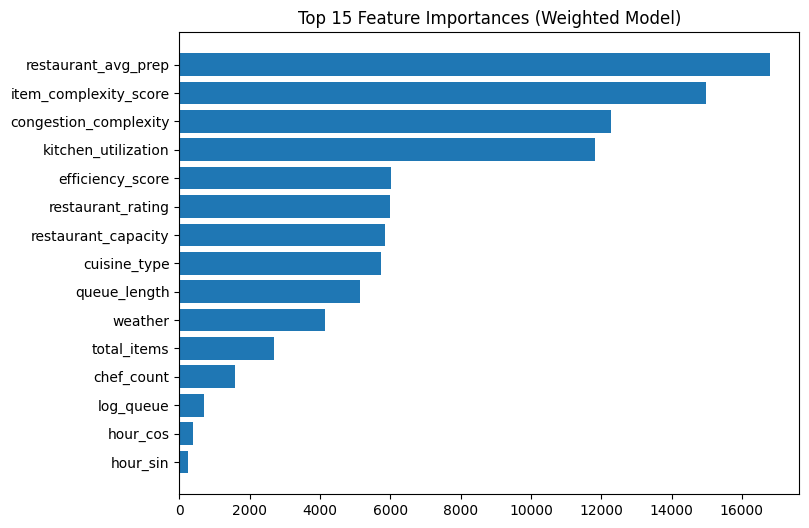


Weighted model saved successfully.


In [2]:
# ==========================================
# CONGESTION-WEIGHTED LIGHTGBM TRAINING
# ==========================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Dataset shape:", df.shape)

# ==========================================
# CREATE CONGESTION WEIGHTS
# ==========================================

# Higher weight for stressed kitchen states
weights = np.where(
    X["kitchen_utilization"] > 0.8,
    2.5,   # stressed samples get more importance
    1.0
)

# ==========================================
# TIME SERIES CROSS VALIDATION
# ==========================================

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

print("\nRunning TimeSeries Cross Validation (Weighted)...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    w_train = weights[train_idx]

    model = lgb.LGBMRegressor(
        objective="huber",
        alpha=0.9,
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=10,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.3,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=w_train,
        eval_set=[(X_val, y_val)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    mae_scores.append(mae)

    print(f"Fold {fold+1} MAE: {round(mae, 3)}")

print("\nAverage CV MAE:", round(np.mean(mae_scores), 3))

# ==========================================
# FINAL TRAIN-TEST SPLIT (80-20)
# ==========================================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

w_train = weights[:split_index]

# ==========================================
# FINAL MODEL TRAINING
# ==========================================

final_model = lgb.LGBMRegressor(
    objective="huber",
    alpha=0.9,
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=10,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.3,
    random_state=42
)

final_model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(100)]
)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = final_model.predict(X_test)

# ==========================================
# EVALUATION METRICS
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nFINAL TEST PERFORMANCE (Weighted)")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 4))

# ==========================================
# CONGESTION PERFORMANCE
# ==========================================

df_test = df.iloc[split_index:].copy()
df_test["prediction"] = y_pred

congestion_condition = df_test["kitchen_utilization"] > 0.8

mae_congestion = mean_absolute_error(
    df_test[congestion_condition]["prep_time"],
    df_test[congestion_condition]["prediction"]
)

mae_normal = mean_absolute_error(
    df_test[~congestion_condition]["prep_time"],
    df_test[~congestion_condition]["prediction"]
)

print("\nMAE during Congestion:", round(mae_congestion, 3))
print("MAE during Normal:", round(mae_normal, 3))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Feature Importances:\n")
print(importances.head(15))

plt.figure(figsize=(8,6))
plt.barh(importances["feature"][:15], importances["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Weighted Model)")
plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(final_model, "kpt_weighted_lightgbm.pkl")
print("\nWeighted model saved successfully.")

In [3]:
# ==========================================
# DUAL-REGIME LIGHTGBM MODEL
# ==========================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

# 80-20 time split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# ==========================================
# DEFINE REGIMES
# ==========================================

threshold = 0.8

normal_mask_train = X_train["kitchen_utilization"] < threshold
cong_mask_train = X_train["kitchen_utilization"] >= threshold

normal_mask_test = X_test["kitchen_utilization"] < threshold
cong_mask_test = X_test["kitchen_utilization"] >= threshold

# Split datasets
X_train_normal = X_train[normal_mask_train]
y_train_normal = y_train[normal_mask_train]

X_train_cong = X_train[cong_mask_train]
y_train_cong = y_train[cong_mask_train]

print("Normal training samples:", len(X_train_normal))
print("Congestion training samples:", len(X_train_cong))

# ==========================================
# MODEL A: NORMAL REGIME
# ==========================================

model_normal = lgb.LGBMRegressor(
    objective="huber",
    alpha=0.9,
    n_estimators=1200,
    learning_rate=0.04,
    num_leaves=48,
    max_depth=8,
    random_state=42
)

model_normal.fit(X_train_normal, y_train_normal)

# ==========================================
# MODEL B: CONGESTED REGIME
# ==========================================

model_cong = lgb.LGBMRegressor(
    objective="huber",
    alpha=0.9,
    n_estimators=1600,
    learning_rate=0.03,
    num_leaves=96,
    max_depth=12,
    random_state=42
)

model_cong.fit(X_train_cong, y_train_cong)

# ==========================================
# PREDICTION WITH ROUTING
# ==========================================

y_pred = np.zeros(len(X_test))

# Predict normal
y_pred[normal_mask_test.values] = model_normal.predict(
    X_test[normal_mask_test]
)

# Predict congestion
y_pred[cong_mask_test.values] = model_cong.predict(
    X_test[cong_mask_test]
)

# ==========================================
# EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nDUAL MODEL PERFORMANCE")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 4))

# Congestion specific
mae_cong = mean_absolute_error(
    y_test[cong_mask_test],
    y_pred[cong_mask_test]
)

mae_normal = mean_absolute_error(
    y_test[normal_mask_test],
    y_pred[normal_mask_test]
)

print("\nMAE during Congestion:", round(mae_cong, 3))
print("MAE during Normal:", round(mae_normal, 3))

# ==========================================
# SAVE MODELS
# ==========================================

joblib.dump(model_normal, "kpt_normal_model.pkl")
joblib.dump(model_cong, "kpt_congestion_model.pkl")

print("\nDual models saved successfully.")

Normal training samples: 405221
Congestion training samples: 35180
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024852 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1115
[LightGBM] [Info] Number of data points in the train set: 405221, number of used features: 17
[LightGBM] [Info] Start training from score 22.281169
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 35180, number of used features: 17
[LightGBM] [Info] Start training from score 38.834086
[LightGBM] [Warning] No further splits with

Dataset shape: (550502, 19)

Running TimeSeries Cross Validation...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1303
[LightGBM] [Info] Number of data points in the train set: 91752, number of used features: 18
[LightGBM] [Info] Start training from score 29.170988
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

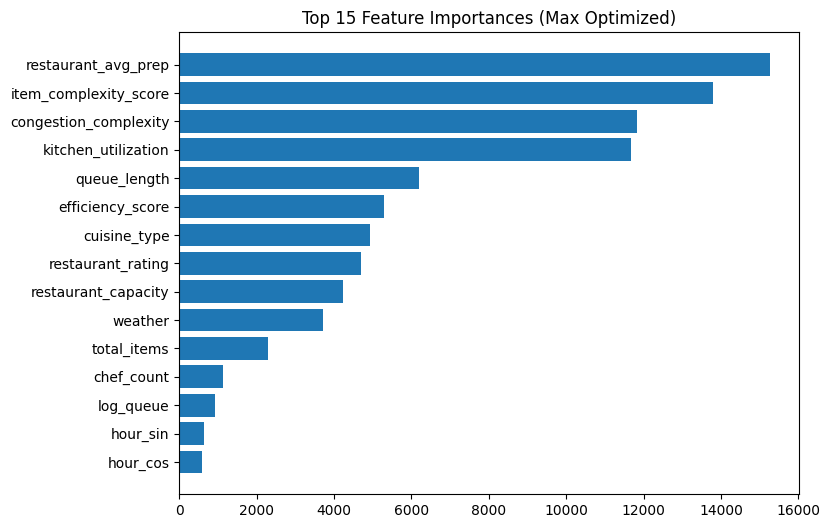


Final optimized model saved successfully.


In [6]:
# ==========================================
# FINAL MAX-OPTIMIZED SINGLE MODEL PIPELINE
# ==========================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("zomato_kpt_feature_engineered.csv")

# ==========================================
# ADD CONGESTION REGIME FEATURE
# ==========================================

df["congestion_regime"] = pd.cut(
    df["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3]
).astype(float).fillna(-1).astype(int) # Convert to float before fillna

# ==========================================
# SPLIT FEATURES / TARGET
# ==========================================

X = df.drop(columns=["prep_time"])
y = df["prep_time"]

print("Dataset shape:", df.shape)

# ==========================================
# TIME SERIES CROSS VALIDATION
# ==========================================

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

print("\nRunning TimeSeries Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Smooth congestion weighting
    weights = 1 + (X_train["kitchen_utilization"] ** 2) * 2

    model = lgb.LGBMRegressor(
        objective="huber",
        alpha=0.9,
        n_estimators=1400,
        learning_rate=0.035,
        num_leaves=64,
        max_depth=10,
        min_child_samples=35,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.15,
        reg_lambda=0.35,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
        eval_set=[(X_val, y_val)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    mae_scores.append(mae)

    print(f"Fold {fold+1} MAE: {round(mae, 3)}")

print("\nAverage CV MAE:", round(np.mean(mae_scores), 3))

# ==========================================
# FINAL TRAIN-TEST SPLIT (80-20)
# ==========================================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Smooth weights for final training
final_weights = 1 + (X_train["kitchen_utilization"] ** 2) * 2

# ==========================================
# FINAL MODEL TRAINING
# ==========================================

final_model = lgb.LGBMRegressor(
    objective="huber",
    alpha=0.9,
    n_estimators=1400,
    learning_rate=0.035,
    num_leaves=64,
    max_depth=10,
    min_child_samples=35,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.15,
    reg_lambda=0.35,
    random_state=42
)

final_model.fit(
    X_train,
    y_train,
    sample_weight=final_weights,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(100)]
)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = final_model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nFINAL TEST PERFORMANCE (Max Optimized)")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 4))

# Congestion evaluation
df_test = df.iloc[split_index:].copy()
df_test["prediction"] = y_pred

congestion_condition = df_test["kitchen_utilization"] > 0.8

mae_cong = mean_absolute_error(
    df_test[congestion_condition]["prep_time"],
    df_test[congestion_condition]["prediction"]
)

mae_normal = mean_absolute_error(
    df_test[~congestion_condition]["prep_time"],
    df_test[~congestion_condition]["prediction"]
)

print("\nMAE during Congestion:", round(mae_cong, 3))
print("MAE during Normal:", round(mae_normal, 3))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Feature Importances:\n")
print(importances.head(15))

plt.figure(figsize=(8,6))
plt.barh(importances["feature"][:15], importances["importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Max Optimized)")
plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(final_model, "kpt_final_max_optimized.pkl")
print("\nFinal optimized model saved successfully.")

**Selecting the final training pipeline as the best model to go forward with**
Why This Pipeline Was Selected
1. Best Congestion Performance

Significant reduction in congestion MAE (from >3.3 to ~2.7).

2. Higher R²

Explains ~87% of prep time variance.

3. Stable Cross Validation

Average CV MAE ≈ 2.02 across 5 time folds.

4. Clean Deployment Architecture

Single model
No routing logic
Easy to productionize

5. Strong Feature Interpretability

Top drivers:

Restaurant historical average prep

Item complexity

Kitchen utilization

Congestion complexity

Queue length

These align with real-world operational intuition.